In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

from tqdm import trange

In [2]:
torch.manual_seed(0)
np.random.seed(0)

In [3]:
N_FACTORS = 50

PERCENTAGE_TEST = 0.2
WEIGHT_DECAY = 0.3
LR = 1e-3

In [4]:
df = pd.read_csv("data/movie_rating/ratings.csv")
df

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [5]:
# [0, 5] -> [0, 1]
df["rating"] = df["rating"] / 5

In [6]:
table = pd.pivot_table(df, index='userId', columns='movieId', values='rating', fill_value=-1)
table

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,0.8,-1.0,0.8,-1.0,-1.0,0.8,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
5,0.8,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,0.5,-1.0,-1.0,-1.0,-1.0,-1.0,0.5,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
607,0.8,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
608,0.5,0.4,0.4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.8,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [7]:
# percentage of value missing from the table
(table < 0).sum().sum() / (table.shape[0] * table.shape[1]) * 100

98.30003169443864

In [8]:
data = torch.tensor(table.values)
data

tensor([[ 0.8000, -1.0000,  0.8000,  ..., -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
        ...,
        [ 0.5000,  0.4000,  0.4000,  ..., -1.0000, -1.0000, -1.0000],
        [ 0.6000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
        [ 1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000]],
       dtype=torch.float64)

In [9]:
def get_test(data):
  ''' Return dictionary with cells index along with it's value '''
  i, j = torch.where(data > 0)
  l = np.array(list(zip(i.detach().numpy(), j.detach().numpy())))
  N = len(l)
  cells = np.random.permutation(l)[:int(N*PERCENTAGE_TEST)]
  d = {}
  for c in map(tuple, cells):
    d[c] = data[c].item()
    data[c] = -1
  return d

test_truth = get_test(data)

In [10]:
class MF(torch.nn.Module):
  def __init__(self, n_factors, shape):
    super().__init__()
    self.n_users, self.n_movies = shape
    self.user_factors = torch.nn.Parameter(torch.rand((self.n_users, n_factors)) - 0.5)
    self.user_bias = torch.nn.Parameter(torch.zeros((self.n_users, 1)))
    self.movie_factors = torch.nn.Parameter(torch.rand((self.n_movies, n_factors)) - 0.5)
    self.movie_bias = torch.nn.Parameter(torch.zeros((self.n_movies, 1)))
  
  def forward(self):
    preds = (self.user_factors+self.user_bias) @ (self.movie_factors+self.movie_bias).T
    return torch.sigmoid(preds)
  
mf = MF(N_FACTORS, data.shape)
optim = torch.optim.Adam(mf.parameters(), lr=0.1, weight_decay=WEIGHT_DECAY)

100%|██████████| 50/50 [00:03<00:00, 16.52it/s]


end loss: 346.1718761425172


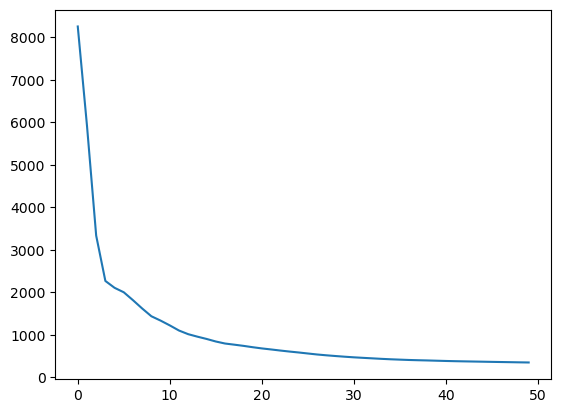

In [11]:
alpha = 0.2
losses = []
for _ in trange(50):
  optim.zero_grad()

  preds = mf.forward()
  difference = (data - preds)**2

  loss = torch.where(data != -1, difference, 0).sum()
  loss.backward()

  losses.append(loss.item())

  optim.step()

plt.plot(losses)
print(f"end loss: {losses[-1]}")

In [12]:
y = []
y_hat = []

for c, v in test_truth.items():
  y.append(v)
  y_hat.append(preds[c].item())

y = np.array(y)
y_hat = np.array(y_hat)

In [13]:
error = np.abs(y_hat - y).mean()
print(f"Error: {error*100:.2f}%")

Error: 14.42%


We have an error rate that is not ideal but is still quite impressive considering the simplicity of the solution and the ammount of missing data.